In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
import zipfile
import os
from pathlib import Path

zip_file_path = Path('C:\\Users\\3PIN\Downloads\\archive (1).zip')
extract_dir =  Path(r'C:\\Users\\3PIN\Downloads\\')

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
  print(f"Successfully unzipped '{zip_file_path}' to '{extract_dir}'")
except zipfile.BadZipFile:
  print(f"Error: '{zip_file_path}' is not a valid zip file or is corrupted.")
except FileNotFoundError:
  print(f"Error: The zip file '{zip_file_path}' was not found.")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Successfully unzipped 'C:\Users\3PIN\Downloads\archive (1).zip' to 'C:\Users\3PIN\Downloads'


In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Flatten
from keras.models import Sequential

In [4]:
#generators
from pathlib import Path
train_ds=keras.utils.image_dataset_from_directory(
    directory=Path(r'C:\\Users\\3PIN\Downloads\\train'),
    labels='inferred',
    label_mode='int',
    batch_size=16,
    image_size=(128,128)

)
test_ds=keras.utils.image_dataset_from_directory(
    directory=Path(r'C:\\Users\\3PIN\Downloads\\test'),
    labels='inferred',
    label_mode='int',
    batch_size=16,
    image_size=(128,128)

)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [5]:
# Normalize

def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label

In [6]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [7]:
train_ds=train_ds.map(process)
test_ds=test_ds.map(process)

In [8]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Base Model: Google ka MobileNetV2 (Isne pehle hi millions photos dekhi hain)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3), # CPU ke liye 128x128 rakho, 256 bohot bhari hai
    include_top=False,         # Iska purana output layer hata do
    weights='imagenet'         # Iske paas pehle se 'knowledge' hai
)

# 2. Freeze the Base: Ise hum dobara train nahi karenge (Time bachega)
base_model.trainable = False

# 3. Naya Model Build Karo
model = models.Sequential([
    base_model,
    layers.Resizing(128, 128),
    # Flatten ki jagah GlobalAveragePooling use karo (Ye RAM bachata hai)
    layers.GlobalAveragePooling2D(), 
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), # Aapki fav layer
    layers.Dropout(0.2),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid') # Final: Cat or Dog
])

# 4. Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 128, 128, 1280) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,785 (9.27 MB)

 Trainable params: 172,545 (674.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [10]:
history = model.fit(
    train_ds,
    epochs=10,
    steps_per_epoch=100, # <--- Sirf 100 steps (Total 5 minute lagenge)
    validation_data=test_ds,
    validation_steps=20   # <--- Validation ko bhi chota rakho
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - accuracy: 0.9269 - loss: 0.1703 - val_accuracy: 0.9500 - val_loss: 0.1053
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 426s 4s/step - accuracy: 0.9419 - loss: 0.1409 - val_accuracy: 0.9469 - val_loss: 0.1232
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 447s 4s/step - accuracy: 0.9544 - loss: 0.1338 - val_accuracy: 0.9563 - val_loss: 0.0953
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 455s 5s/step - accuracy: 0.9544 - loss: 0.1318 - val_accuracy: 0.9500 - val_loss: 0.1086
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.9450 - loss: 0.1393 - val_accuracy: 0.9563 - val_loss: 0.0874
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.9675 - loss: 0.1015 - val_accuracy: 0.9500 - val_loss: 0.1136
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - accuracy: 0.9588 - loss: 0.1077 - val_accuracy: 0.9625 - val_loss: 0.0930
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.9569 - loss: 0.1050 - val_accu

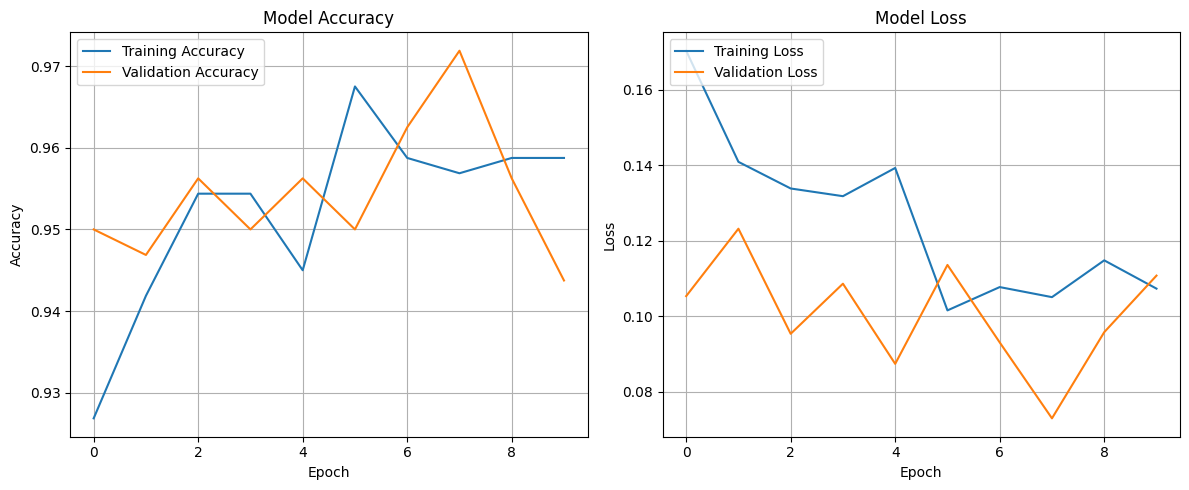

In [11]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )
plt.tight_layout()
plt.show()

In [13]:
%pip install opencv-python


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 5.6 MB/s eta 0:00:08
   - -------------------------------------- 1.3/40.2 MB 3.2 MB/s eta 0:00:13
   -- ------------------------------------- 2.1/40.2 MB 3.6 MB/s eta 0:00:11
   --- ------------------------------------ 3.1/40.2 MB 3.9 MB/s eta 0:00:10
   --- ------------------------------------ 3.9/40.2 MB 3.9 MB/s eta 0:00:10
   ---- ----------------------------------- 4.5/40.2 MB 3.5 MB/s eta 0:00:11
   ----- ---------------------------------- 5.2/40.2 MB 3.5 MB/s eta 0:00:10
   ------ --------------------------------- 6.3/40.2 MB 3.6 MB/s eta 0:00:10
   ------ --------------------------------- 6.8/40.2 MB 3.6 MB/s eta 0:00:10
   -------- ------------------------------- 8.1/40.2 MB 3.7 MB/s eta 0:00:09
   --------- ------------------------------ 9.4/40.2 MB 3.9 MB/s eta 0:00:08
   ---------- ----------------------------- 10.7/40.2 MB 4.1 MB/s eta 0:00:08
   -

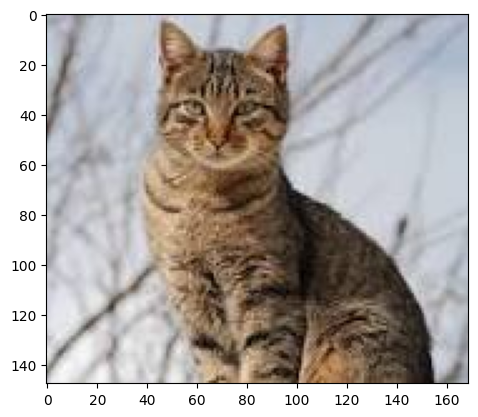

In [28]:
import cv2

cat_img=cv2.imread(Path('C:\\Deep Learning\\Cat_Vs_Dog_Classification\\cat.jfif'))
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB) # DON'T FORGET THIS
plt.imshow(cat_img)

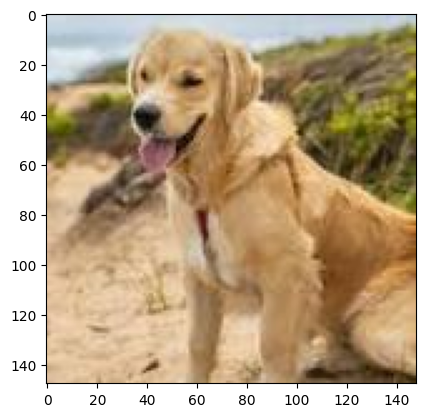

In [29]:
dog_img=cv2.imread(Path('C:\\Deep Learning\\Cat_Vs_Dog_Classification\\dog.jfif'))
dog_img = cv2.cvtColor(dog_img, cv2.COLOR_BGR2RGB) # DON'T FORGET THIS
plt.imshow(dog_img)

In [30]:
print(cat_img.shape)
print(dog_img.shape)

(148, 169, 3)
(148, 148, 3)


In [31]:
cat_img=cv2.resize(cat_img,(128,128))
dog_img=cv2.resize(dog_img,(128,128))

cat_input=cat_img.reshape((1,128,128,3))
dog_input=dog_img.reshape((1,128,128,3))

In [34]:
model.predict(cat_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


array([[0.71251965]], dtype=float32)

In [35]:
model.predict(dog_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


array([[0.7143047]], dtype=float32)

In [39]:
print(np.mean(test_cat))
print(np.mean(test_dog))

-0.0039032476
-0.0039042395


In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def get_clean_image(path):
    # 1. Load & Convert Color
    raw = cv2.imread(path)
    rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    # 2. Resize
    resized = cv2.resize(rgb, (128, 128))
    # 3. Add Batch Dimension (Shape: 1, 128, 128, 3)
    batched = np.expand_dims(resized, axis=0)
    # 4. MobileNet Preprocessing (Scaling happens HERE)
    # DO NOT divide by 255 before this!
    processed = preprocess_input(batched.astype('float32'))
    return processed

# RE-LOAD FRESH
final_cat = get_clean_image((Path('C:\\Deep Learning\\Cat_Vs_Dog_Classification\\cat.jfif')))
final_dog = get_clean_image((Path('C:\\Deep Learning\\Cat_Vs_Dog_Classification\\dog.jfif')))

# VERIFY THEY ARE DIFFERENT
print("Cat Mean:", np.mean(final_cat))
print("Dog Mean:", np.mean(final_dog))

# PREDICT
print("Cat Predict:", model.predict(final_cat))
print("Dog Predict:", model.predict(final_dog))

Cat Mean: 0.19129343
Dog Mean: 0.12681465
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Cat Predict: [[0.00011601]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
Dog Predict: [[0.9999487]]


In [43]:
model.save('cat_dog_cnn_model.keras')
